In [2]:
import os
import shutil

# --- Đường dẫn gốc ---
base1 = r"C:\Users\ASUS\OneDrive\Desktop\Code\DAP391m\Chest_X_Ray_Split"
base2 = r"C:\Users\ASUS\Downloads\Covid19_Pneumonia_Normal_Chest_X_ray"
merged = r"C:\Users\ASUS\OneDrive\Desktop\Code\DAP391m\Merged_Xray_Dataset"

# --- Các nhãn giữ lại ---
classes = ['NORMAL', 'PNEUMONIA']

# --- 1️⃣ Tạo cấu trúc thư mục đích (train, val, test) ---
for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(merged, split, cls), exist_ok=True)

# --- 2️⃣ Copy toàn bộ dữ liệu từ file 1 (đã chia sẵn) ---
for split in ['train', 'val', 'test']:
    for cls in classes:
        src_dir = os.path.join(base1, split, cls)
        dst_dir = os.path.join(merged, split, cls)
        for file in os.listdir(src_dir):
            shutil.copy2(os.path.join(src_dir, file), dst_dir)

print("✅ Đã sao chép dữ liệu từ file 1 (train/val/test).")

# --- 3️⃣ Chỉ thêm ảnh từ file 2 vào tập train ---
for cls in classes:
    src_dir = os.path.join(base2, cls)
    if not os.path.exists(src_dir):
        continue

    dst_dir = os.path.join(merged, 'train', cls)
    for file in os.listdir(src_dir):
        src_path = os.path.join(src_dir, file)
        shutil.copy2(src_path, dst_dir)

print("✅ Đã thêm ảnh từ file Covid19_Pneumonia_Normal_Chest_X_ray vào tập train.")
print("🎉 Hoàn tất gộp dữ liệu tại:", merged)


✅ Đã sao chép dữ liệu từ file 1 (train/val/test).
✅ Đã thêm ảnh từ file Covid19_Pneumonia_Normal_Chest_X_ray vào tập train.
🎉 Hoàn tất gộp dữ liệu tại: C:\Users\ASUS\OneDrive\Desktop\Code\DAP391m\Merged_Xray_Dataset


📊 Số lượng ảnh chi tiết:
           train  val  test  Tổng
NORMAL      2910  237   238  3385
PNEUMONIA   4791  640   642  6073

🔢 Tổng số ảnh toàn bộ dataset: 9458


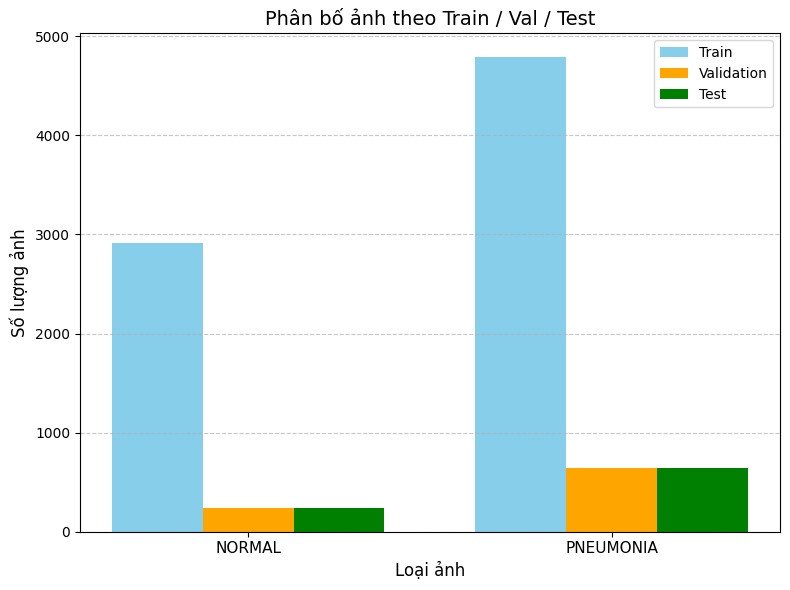

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_combined_distribution(data_dir):
    sets, classes = ["train", "val", "test"], ["NORMAL", "PNEUMONIA"]
    
    # Đếm số ảnh
    counts = {
        s: [len(os.listdir(os.path.join(data_dir, s, cls))) for cls in classes]
        for s in sets
    }

    # Tạo DataFrame để hiển thị bảng
    df = pd.DataFrame(counts, index=classes)
    df["Tổng"] = df.sum(axis=1)
    total_all = df["Tổng"].sum()

    print("📊 Số lượng ảnh chi tiết:")
    print(df)
    print(f"\n🔢 Tổng số ảnh toàn bộ dataset: {total_all}")

    # --- Vẽ biểu đồ ---
    x = np.arange(len(classes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8,6))
    ax.bar(x - width, df['train'], width, label='Train', color='skyblue')
    ax.bar(x,         df['val'],   width, label='Validation', color='orange')
    ax.bar(x + width, df['test'],  width, label='Test', color='green')

    ax.set_xlabel("Loại ảnh", fontsize=12)
    ax.set_ylabel("Số lượng ảnh", fontsize=12)
    ax.set_title("Phân bố ảnh theo Train / Val / Test", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=11)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- Ví dụ chạy ---
data_dir = r"C:\Users\ASUS\OneDrive\Desktop\Code\DAP391m\Merged_Xray_Dataset"
plot_combined_distribution(data_dir)


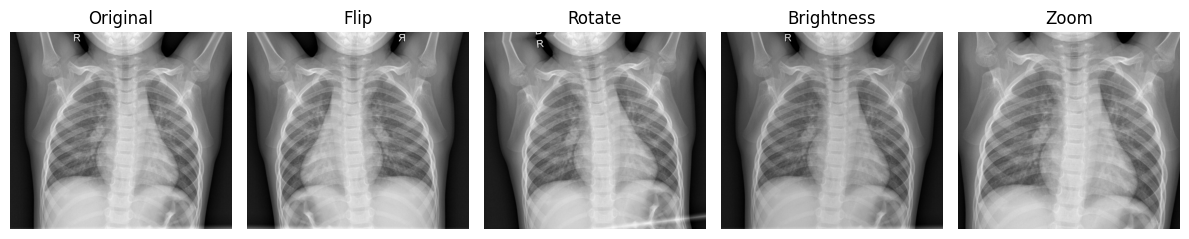

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random

# ---- Các hàm augment ----
def augment_flip(img):
    return cv2.flip(img, 1)

def augment_rotate(img, angle=15):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def augment_brightness(img, factor=1.3):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(float)
    hsv[:,:,2] = hsv[:,:,2] * factor
    hsv[:,:,2][hsv[:,:,2] > 255] = 255
    return cv2.cvtColor(hsv.astype('uint8'), cv2.COLOR_HSV2BGR)

def augment_zoom(img, zoom_factor=1.1):
    h, w = img.shape[:2]
    center = (w//2, h//2)
    M = cv2.getRotationMatrix2D(center, 0, zoom_factor)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

# ---- Load 1 ảnh ví dụ ----
img_path = r"C:\Users\ASUS\OneDrive\Desktop\Code\DAP391m\Chest_X_Ray_Split\train\NORMAL\IM-0115-0001.jpeg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---- Tạo các phiên bản augment ----
img_flip = augment_flip(img)
img_rotate = augment_rotate(img, angle=random.randint(-15,15))
img_bright = augment_brightness(img, factor=random.uniform(0.8,1.4))
img_zoom = augment_zoom(img, zoom_factor=random.uniform(0.9,1.2))

# ---- Hiển thị kết quả ----
titles = ['Original', 'Flip', 'Rotate', 'Brightness', 'Zoom']
images = [img, img_flip, img_rotate, img_bright, img_zoom]

plt.figure(figsize=(12, 6))
for i, (title, im) in enumerate(zip(titles, images)):
    plt.subplot(1, 5, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [7]:
import os
import cv2
import random
import numpy as np

# ---------------- Augmentation functions ----------------
def augment_flip(img):
    return cv2.flip(img, 1)

def augment_rotate(img, angle=15):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

def augment_brightness(img, factor=1.3):
    hsv = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), cv2.COLOR_BGR2HSV).astype(float)
    hsv[:,:,2] = hsv[:,:,2] * factor
    hsv[:,:,2][hsv[:,:,2] > 255] = 255
    return cv2.cvtColor(hsv.astype('uint8'), cv2.COLOR_HSV2BGR)[:,:,0]

def augment_zoom(img, zoom_factor=1.1):
    h, w = img.shape[:2]
    center = (w//2, h//2)
    M = cv2.getRotationMatrix2D(center, 0, zoom_factor)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

aug_funcs = [augment_flip, augment_rotate, augment_brightness, augment_zoom]

# ---------------- Resize + Grayscale + Copy ----------------
def preprocess_images(input_dir, output_dir, target_size=(224,224)):
    os.makedirs(output_dir, exist_ok=True)
    for split in ['train', 'val', 'test']:
        split_input = os.path.join(input_dir, split)
        split_output = os.path.join(output_dir, split)
        os.makedirs(split_output, exist_ok=True)

        for class_name in os.listdir(split_input):
            class_input = os.path.join(split_input, class_name)
            class_output = os.path.join(split_output, class_name)
            os.makedirs(class_output, exist_ok=True)

            imgs = [f for f in os.listdir(class_input) if f.lower().endswith(('.png','.jpg','.jpeg'))]
            print(f"Processing {split}/{class_name} with {len(imgs)} images.")

            for filename in imgs:
                src_path = os.path.join(class_input, filename)
                dst_path = os.path.join(class_output, filename)
                img = cv2.imread(src_path)
                if img is None:
                    continue

                # Chuyển grayscale
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                # Resize
                gray = cv2.resize(gray, target_size, interpolation=cv2.INTER_AREA)
                cv2.imwrite(dst_path, gray)

# ---------------- Augment & Balance Train Set ----------------
def balance_train_classes(train_dir, target_num=5000):
    for class_name in os.listdir(train_dir):
        class_dir = os.path.join(train_dir, class_name)
        imgs = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        count = len(imgs)
        print(f"{class_name}: {count} images before augment")

        if count < target_num:
            needed = target_num - count
            print(f"Augmenting {needed} images in {class_name}...")

            for i in range(needed):
                src_file = os.path.join(class_dir, random.choice(imgs))
                img = cv2.imread(src_file, cv2.IMREAD_GRAYSCALE)
                func = random.choice(aug_funcs)
                if func == augment_rotate:
                    img_aug = func(img, angle=random.randint(-15,15))
                elif func == augment_brightness:
                    img_aug = func(img, factor=random.uniform(0.8,1.4))
                elif func == augment_zoom:
                    img_aug = func(img, zoom_factor=random.uniform(0.9,1.2))
                else:
                    img_aug = func(img)

                dst_file = os.path.join(class_dir, f"aug_{i}_{os.path.basename(src_file)}")
                cv2.imwrite(dst_file, img_aug)

        elif count > target_num:
            print(f"Class {class_name} có {count} ảnh, không augment thêm.")
        else:
            print(f"{class_name} đã đủ {target_num} ảnh.")

    print("\n✅ Cân bằng hoàn tất! Kết quả cuối cùng:")
    for class_name in os.listdir(train_dir):
        c_dir = os.path.join(train_dir, class_name)
        imgs = len([f for f in os.listdir(c_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        print(f"{class_name}: {imgs} ảnh")

# ---------------- Run toàn bộ pipeline ----------------
input_folder = r"C:\Users\ASUS\OneDrive\Desktop\Code\DAP391m\Merged_Xray_Dataset"
output_folder = r"C:\Users\ASUS\OneDrive\Desktop\Code\DAP391m\Processed_XRay_Dataset"

preprocess_images(input_folder, output_folder)
balance_train_classes(os.path.join(output_folder, "train"), target_num=5000)

print("\n🎯 Toàn bộ ảnh đã được resize 224x224, chuyển grayscale, và cân bằng 50/50.")


Processing train/NORMAL with 2910 images.
Processing train/PNEUMONIA with 4791 images.
Processing val/NORMAL with 237 images.
Processing val/PNEUMONIA with 640 images.
Processing test/NORMAL with 238 images.
Processing test/PNEUMONIA with 642 images.
NORMAL: 2910 images before augment
Augmenting 2090 images in NORMAL...
PNEUMONIA: 4791 images before augment
Augmenting 209 images in PNEUMONIA...

✅ Cân bằng hoàn tất! Kết quả cuối cùng:
NORMAL: 5000 ảnh
PNEUMONIA: 5000 ảnh

🎯 Toàn bộ ảnh đã được resize 224x224, chuyển grayscale, và cân bằng 50/50.
